<a href="https://colab.research.google.com/github/rmoy1-clt/Intro-to-ML/blob/main/HW1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
file_path = '/content/drive/My Drive/Intro-to-ML/Datasets/D3.csv'
df = pd.DataFrame(pd.read_csv(file_path))
print(df.head())

         X1        X2        X3         Y
0  0.000000  3.440000  0.440000  4.387545
1  0.040404  0.134949  0.888485  2.679650
2  0.080808  0.829899  1.336970  2.968490
3  0.121212  1.524848  1.785455  3.254065
4  0.161616  2.219798  2.233939  3.536375


Gradient Descent Equation


In [7]:
def gradient_descent(X, y, alpha=0.05, n_iter=2000, tol=1e-9):
    """
    X: (m, n) explanatory variable matrix (no bias column)
    y: (m,) target vector
    alpha: learning rate
    n_iter: max number of iterations
    tol: stop early if cost stops improving by more than tol

    theta is initialized to zero, as required.
    """
    m, n = X.shape
    Xb = np.hstack([np.ones((m, 1)), X])   # add intercept/bias column
    theta = np.zeros(n + 1)
    cost_history = []

    for it in range(n_iter):
        h = Xb @ theta
        error = h - y
        cost = (1 / (2 * m)) * np.sum(error ** 2)
        cost_history.append(cost)

        grad = (1 / m) * (Xb.T @ error)
        theta = theta - alpha * grad          # simultaneous update

        if tol is not None and it > 0 and abs(cost_history[-2] - cost) < tol:
            break

    return theta, cost_history

def predict(theta, X):
    m = X.shape[0]
    Xb = np.hstack([np.ones((m, 1)), X])
    return Xb @ theta

# Problem 1

## Linear Model
Finding best learning rate by finding cost and amount of iterations til converging

Equation: htheta(x)= theta0 + theta1*x

In [17]:
# Separate features and labels
X1 = df[['X1']].values
X2 = df[['X2']].values
X3 = df[['X3']].values
y  = df['Y'].values
learning_rates = [0.1, 0.05, 0.01]
N_ITER = 2000

# Display first 5 records and the total number of training examples
print('X1 = ', X1[: 5])
print('X2 = ', X2[: 5])
print('X3 = ', X3[: 5])
print('y = ', y[: 5])

#Linear Model
univariate_results = {}
for name, X in [('X1', X1), ('X2', X2), ('X3', X3)]:
    univariate_results[name] = {}
    for lr in learning_rates:
        theta, cost_hist = gradient_descent(X, y, alpha=lr, n_iter=N_ITER)
        univariate_results[name][lr] = (theta, cost_hist)
        print(f"{name}, lr={lr:<5} -> theta={np.round(theta,4)}, "
              f"final cost={cost_hist[-1]:.6f}, iterations to converge={len(cost_hist)}")

X1 =  [[0.        ]
 [0.04040404]
 [0.08080808]
 [0.12121212]
 [0.16161616]]
X2 =  [[3.44      ]
 [0.1349495 ]
 [0.82989899]
 [1.52484848]
 [2.21979798]]
X3 =  [[0.44      ]
 [0.88848485]
 [1.3369697 ]
 [1.78545454]
 [2.23393939]]
y =  [4.38754501 2.6796499  2.96848981 3.25406475 3.53637472]
X1, lr=0.1   -> theta=[ 5.9275 -2.0382], final cost=0.984993, iterations to converge=428
X1, lr=0.05  -> theta=[ 5.9274 -2.0381], final cost=0.984993, iterations to converge=827
X1, lr=0.01  -> theta=[ 5.8589 -2.0115], final cost=0.985605, iterations to converge=2000
X2, lr=0.1   -> theta=[0.7357 0.5578], final cost=3.599366, iterations to converge=314
X2, lr=0.05  -> theta=[0.7355 0.5578], final cost=3.599366, iterations to converge=597
X2, lr=0.01  -> theta=[0.7307 0.5597], final cost=3.599370, iterations to converge=2000
X3, lr=0.1   -> theta=[ 2.871  -0.5203], final cost=3.629451, iterations to converge=388
X3, lr=0.05  -> theta=[ 2.8709 -0.5203], final cost=3.629451, iterations to converge=747

## Found best learning rate was 0.1

In [9]:
best_lr = 0.1
for name in ['X1', 'X2', 'X3']:
    theta, _ = univariate_results[name][best_lr]
    print(f"Y = {theta[0]:.4f} + ({theta[1]:.4f}) * {name}")

Y = 5.9275 + (-2.0382) * X1
Y = 0.7357 + (0.5578) * X2
Y = 2.8710 + (-0.5203) * X3


## Plots for regression fit and loss curve per variable

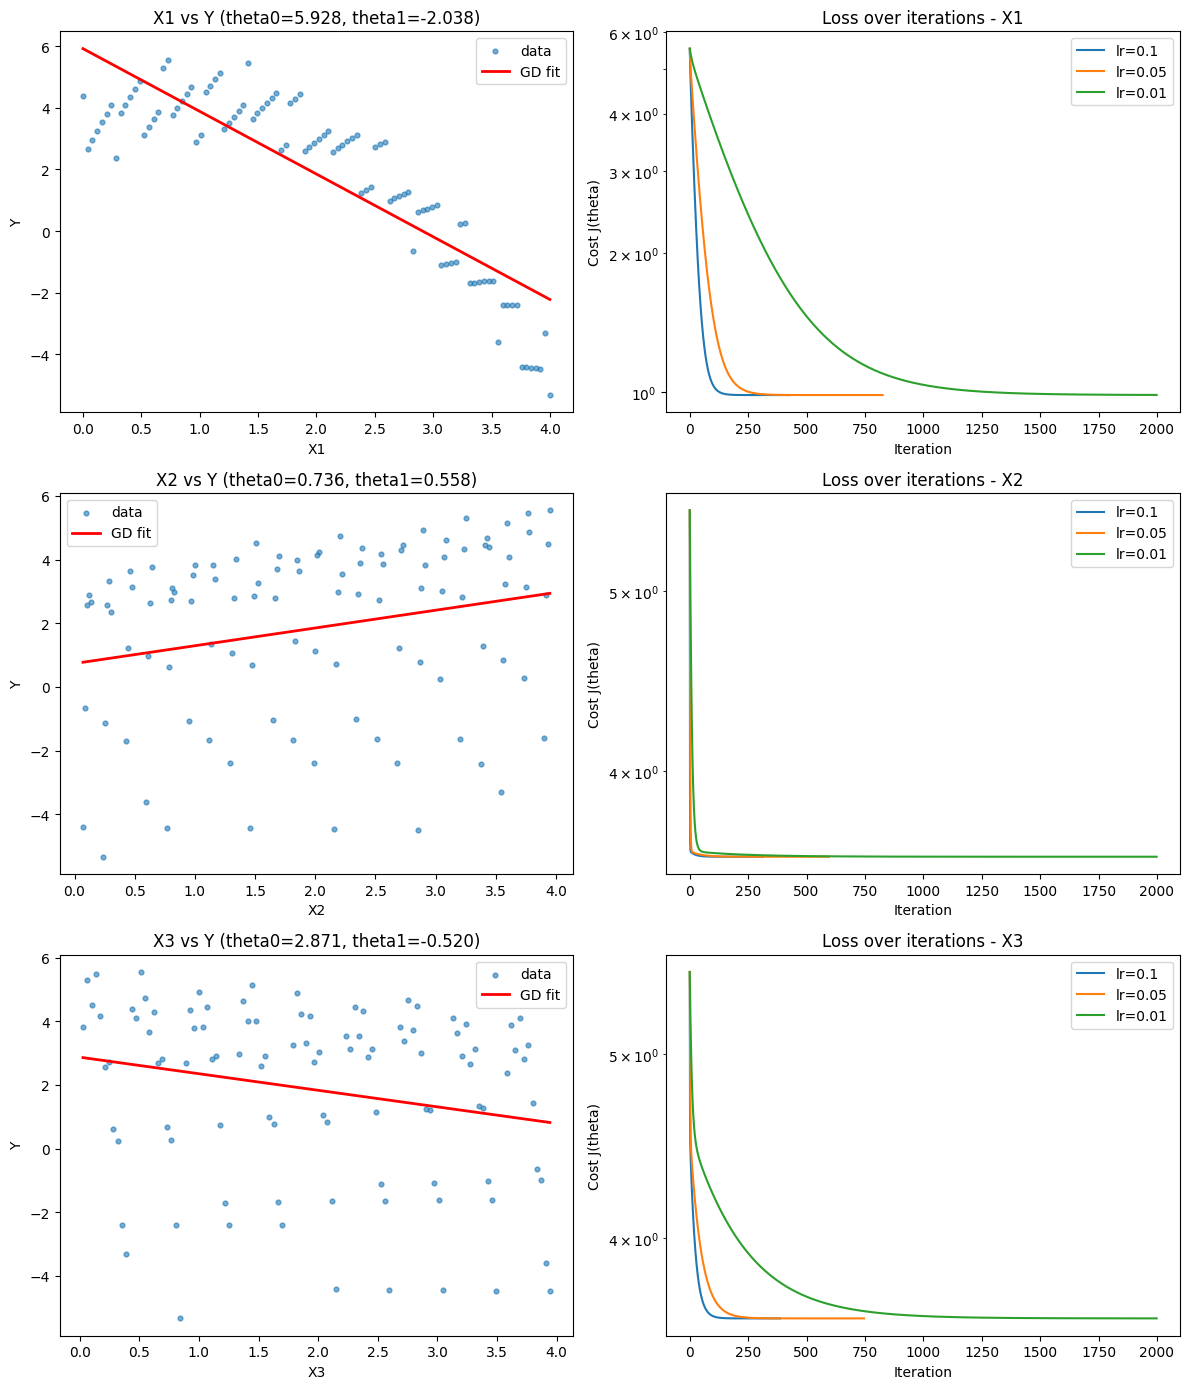

In [10]:
fig, axes = plt.subplots(3, 2, figsize=(12, 14))
for i, name in enumerate(['X1', 'X2', 'X3']):
    theta, cost_hist = univariate_results[name][best_lr]
    X = df[[name]].values

    ax = axes[i, 0]
    ax.scatter(X, y, s=12, alpha=0.6, label='data')
    x_line = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
    y_line = predict(theta, x_line)
    ax.plot(x_line, y_line, color='red', linewidth=2, label='GD fit')
    ax.set_xlabel(name); ax.set_ylabel('Y')
    ax.set_title(f'{name} vs Y (theta0={theta[0]:.3f}, theta1={theta[1]:.3f})')
    ax.legend()

    ax2 = axes[i, 1]
    for lr in learning_rates:
        _, ch = univariate_results[name][lr]
        ax2.plot(ch, label=f'lr={lr}')
    ax2.set_xlabel('Iteration'); ax2.set_ylabel('Cost J(theta)')
    ax2.set_title(f'Loss over iterations - {name}')
    ax2.set_yscale('log')
    ax2.legend()

plt.tight_layout()
plt.savefig('problem1_plots.png', bbox_inches='tight')
plt.show()

## Finding lowest cost varaible

In [11]:
for name in ['X1', 'X2', 'X3']:
    _, ch = univariate_results[name][best_lr]
    print(f"{name}: final cost = {ch[-1]:.6f}")

X1: final cost = 0.984993
X2: final cost = 3.599366
X3: final cost = 3.629451


# Problem 2

## Multiple linear regression: htheta(x)=theta0 + theta1*x1 + theta2*x2 + theta3*x3

In [12]:
X_all = df[['X1', 'X2', 'X3']].values

multi_results = {}
for lr in learning_rates:
    theta, cost_hist = gradient_descent(X_all, y, alpha=lr, n_iter=N_ITER)
    multi_results[lr] = (theta, cost_hist)
    print(f"lr={lr:<5} -> theta={np.round(theta,4)}, final cost={cost_hist[-1]:.6f}, "
          f"iterations to converge={len(cost_hist)}")

lr=0.1   -> theta=[ 5.3132 -2.0036  0.5327 -0.2655], final cost=0.738464, iterations to converge=859
lr=0.05  -> theta=[ 5.3128 -2.0035  0.5328 -0.2654], final cost=0.738464, iterations to converge=1651
lr=0.01  -> theta=[ 4.6078 -1.9039  0.6493 -0.1621], final cost=0.765093, iterations to converge=2000


## Best learning rate (0.1) again

In [13]:
best_lr_multi = 0.1
theta_best, cost_hist_best = multi_results[best_lr_multi]
print(f"Y = {theta_best[0]:.4f} + ({theta_best[1]:.4f})*X1 + ({theta_best[2]:.4f})*X2 + ({theta_best[3]:.4f})*X3")

Y = 5.3132 + (-2.0036)*X1 + (0.5327)*X2 + (-0.2655)*X3


## Plotting Loss over iterations

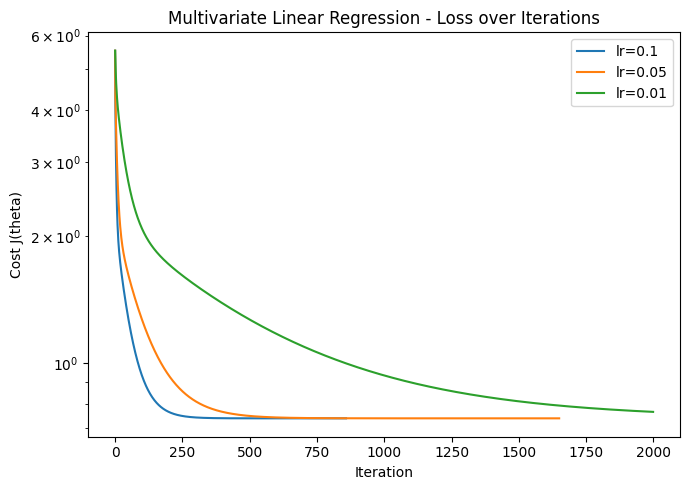

In [14]:
plt.figure(figsize=(7, 5))
for lr in learning_rates:
    _, ch = multi_results[lr]
    plt.plot(ch, label=f'lr={lr}')
plt.xlabel('Iteration'); plt.ylabel('Cost J(theta)')
plt.title('Multivariate Linear Regression - Loss over Iterations')
plt.yscale('log')
plt.legend()
plt.tight_layout()
plt.savefig('problem2_loss.png', bbox_inches='tight')
plt.show()

## Predictions

In [16]:
new_points = np.array([[1, 1, 1],
                        [2, 0, 4],
                        [3, 2, 1]])
preds = predict(theta_best, new_points)
for pt, p in zip(new_points, preds):
    print(f"(X1,X2,X3)={tuple(pt)} -> predicted Y = {p:.4f}")

(X1,X2,X3)=(np.int64(1), np.int64(1), np.int64(1)) -> predicted Y = 3.5769
(X1,X2,X3)=(np.int64(2), np.int64(0), np.int64(4)) -> predicted Y = 0.2442
(X1,X2,X3)=(np.int64(3), np.int64(2), np.int64(1)) -> predicted Y = 0.1024
